# Limpeza de Dados em Monitoramento de Frota com IoT

Esta atividade avaliativa usa uma **nova base sintética suja** para que você repita, em outro contexto, o pipeline de tratamento e limpeza de dados estudado anteriormente.

O objetivo é praticar:

- diagnóstico de qualidade dos dados;
- remoção de duplicatas e atributos pouco úteis;
- padronização de categorias;
- conversão de datas e unidades;
- tratamento de inconsistências físicas;
- imputação com média, mediana e moda;
- comparação de outliers por IQR, z-score e DBSCAN;
- salvamento da base limpa para aulas futuras.

A atividade é **semiguiada**: algumas células já trazem uma implementação parcial, e outras pedem que você adapte ou complete a análise.

##**Há várias células onde aparecem ??? nos códigos indicando que você deve completar a implementação**

## 1. Contexto do problema

Uma empresa monitora uma frota de veículos usando dispositivos IoT embarcados. Cada veículo envia registros de telemetria contendo distância percorrida, consumo de combustível, velocidade média, temperatura do motor, vibração, frenagens bruscas e status de manutenção.

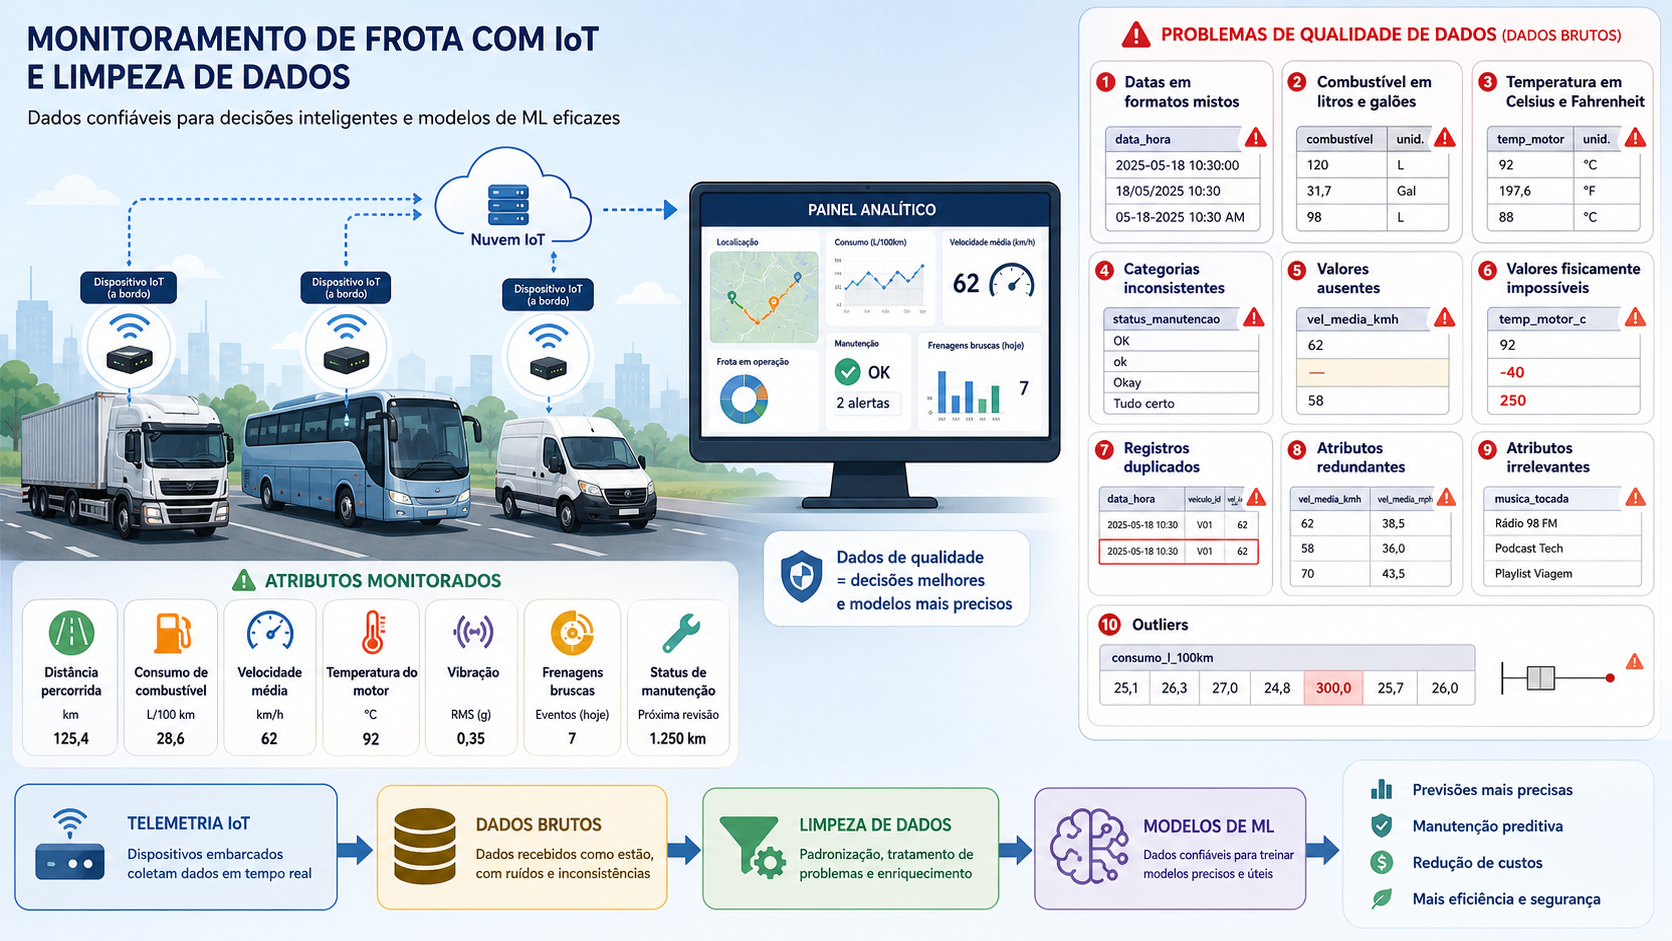

##Limpeza dos dados

Antes de construir modelos de aprendizado de máquina para prever consumo, detectar anomalias ou estimar risco de falha, é necessário limpar os dados.

Nesta base sintética, vamos simular problemas comuns de projetos reais:

- datas em formatos mistos;
- combustível registrado em litros e galões;
- temperatura registrada em Celsius e Fahrenheit;
- categorias inconsistentes;
- valores ausentes;
- valores fisicamente impossíveis;
- registros duplicados;
- atributos redundantes;
- atributos irrelevantes;
- outliers.

## 2. Atributos da base

| Atributo | Tipo esperado | Descrição |
|---|---|---|
| `id_viagem` | Identificador | Código da viagem |
| `data_viagem` | Data/hora | Data e hora da coleta, com formatos mistos na base suja |
| `veiculo` | Categórico | Identificador do veículo, com variações de escrita |
| `tipo_veiculo` | Categórico | Caminhão, ônibus ou van, com grafias inconsistentes |
| `motorista` | Categórico | Nome do motorista |
| `distancia_km` | Numérico | Distância percorrida |
| `distancia_km_backup` | Numérico | Cópia redundante de `distancia_km` |
| `combustivel_registro` | Texto com unidade | Combustível em litros ou galões |
| `velocidade_media_kmh` | Numérico | Velocidade média da viagem |
| `temperatura_motor_registro` | Texto com unidade | Temperatura em Celsius ou Fahrenheit |
| `vibracao_motor_mm_s` | Numérico | Vibração do motor |
| `frenagens_bruscas` | Numérico discreto | Número de frenagens bruscas |
| `tempo_viagem_min` | Numérico | Duração da viagem |
| `consumo_km_l` | Numérico | Consumo aproximado em km/L |
| `status_manutencao` | Categórico | Normal, atenção ou crítico |
| `observacao_operacional` | Texto | Observações livres, com muitos ausentes |
| `codigo_sensor_aleatorio` | Numérico | Código aleatório sem significado analítico |
| `risco_falha` | Categórico alvo | Classe sintética de risco: baixo, médio ou alto |

## 3. Importação das bibliotecas

Nesta célula usamos:

- `numpy` para gerar dados sintéticos;
- `pandas` para manipular tabelas;
- `matplotlib` e `seaborn` para gráficos;
- `re` e `unicodedata` para limpar textos;
- `zscore` para detectar outliers por z-score;
- `StandardScaler` e `DBSCAN` para detecção multivariada de outliers.

In [ ]:
# ------------------------------------------------------------
# 1) Importação de bibliotecas
# ------------------------------------------------------------

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

sns.set_theme(style="whitegrid")

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 4. Geração da base sintética suja

A próxima célula cria os dados sintéticos e salva o arquivo CSV `dados_frota_iot_sujos.csv`.

Principais recursos usados:

- `np.random.default_rng(42)`: gera números aleatórios reprodutíveis;
- `rng.choice(...)`: sorteia categorias;
- `rng.normal(...)`: gera valores numéricos com variação;
- `pd.DataFrame(...)`: cria uma tabela;
- `.loc[...]`: altera valores específicos;
- `pd.concat(...)`: adiciona duplicatas;
- `.to_csv(...)`: salva a base para leitura posterior com `pd.read_csv()`.

In [ ]:
# ------------------------------------------------------------
# 2) Geração da base sintética suja
# ------------------------------------------------------------

rng = np.random.default_rng(42)
n = 520

veiculos = [f"V{str(i).zfill(3)}" for i in range(1, 26)]

tipos_por_veiculo = {}
for v in veiculos:
    numero = int(v[1:])
    if numero <= 9:
        tipos_por_veiculo[v] = "caminhao"
    elif numero <= 17:
        tipos_por_veiculo[v] = "onibus"
    else:
        tipos_por_veiculo[v] = "van"

motoristas_base = [
    "Ana Souza", "Bruno Lima", "Carla Mendes", "Diego Alves",
    "Eduardo Rocha", "Fernanda Costa", "Gustavo Nunes", "Helena Martins",
    "Igor Pereira", "Juliana Castro", "Lucas Ribeiro", "Mariana Torres"
]

veiculo = rng.choice(veiculos, size=n)
tipo_veiculo = np.array([tipos_por_veiculo[v] for v in veiculo])
motorista = rng.choice(motoristas_base, size=n)

datas = pd.date_range(start="2026-03-01 06:00:00", periods=n, freq="3H")

distancia_km = rng.lognormal(mean=4.35, sigma=0.45, size=n)
velocidade_media_kmh = rng.normal(loc=58, scale=12, size=n)
velocidade_media_kmh = np.clip(velocidade_media_kmh, 15, 105)

tempo_viagem_min = (distancia_km / velocidade_media_kmh) * 60 + rng.normal(0, 8, size=n)
tempo_viagem_min = np.clip(tempo_viagem_min, 10, 360)

eficiencia_km_l = np.where(
    tipo_veiculo == "van", 8.5,
    np.where(tipo_veiculo == "onibus", 3.2, 3.8)
)

combustivel_litros = distancia_km / eficiencia_km_l + rng.normal(0, 2.0, size=n)
combustivel_litros = np.clip(combustivel_litros, 2, None)

temperatura_motor_c = (
    82
    + 0.08 * velocidade_media_kmh
    + np.where(tipo_veiculo == "onibus", 4, 0)
    + np.where(tipo_veiculo == "caminhao", 2, 0)
    + rng.normal(0, 4.5, size=n)
)

vibracao_motor_mm_s = (
    2.2
    + np.where(tipo_veiculo == "caminhao", 0.5, 0)
    + np.where(tipo_veiculo == "onibus", 0.3, 0)
    + rng.normal(0, 0.55, size=n)
)
vibracao_motor_mm_s = np.clip(vibracao_motor_mm_s, 0.5, None)

frenagens_bruscas = rng.poisson(
    lam=np.clip((velocidade_media_kmh - 35) / 20, 0.5, 5.0),
    size=n
)

consumo_km_l = distancia_km / combustivel_litros

score_risco = (
    0.05 * np.maximum(0, temperatura_motor_c - 92)
    + 0.9 * np.maximum(0, vibracao_motor_mm_s - 3.0)
    + 0.12 * frenagens_bruscas
    + rng.normal(0, 0.3, size=n)
)

risco_falha = np.where(
    score_risco > 2.0, "alto",
    np.where(score_risco > 0.9, "medio", "baixo")
)

status_manutencao = np.where(
    risco_falha == "alto", "critico",
    np.where(risco_falha == "medio", "atencao", "normal")
)

dados = pd.DataFrame({
    "id_viagem": [f"TRIP-{str(i).zfill(5)}" for i in range(1, n + 1)],
    "data_viagem": datas,
    "veiculo": veiculo,
    "tipo_veiculo": tipo_veiculo,
    "motorista": motorista,
    "distancia_km": distancia_km,
    "distancia_km_backup": distancia_km.copy(),
    "combustivel_litros_limpo": combustivel_litros,
    "velocidade_media_kmh": velocidade_media_kmh,
    "temperatura_motor_c_limpo": temperatura_motor_c,
    "vibracao_motor_mm_s": vibracao_motor_mm_s,
    "frenagens_bruscas": frenagens_bruscas,
    "tempo_viagem_min": tempo_viagem_min,
    "consumo_km_l": consumo_km_l,
    "status_manutencao": status_manutencao,
    "observacao_operacional": np.nan,
    "codigo_sensor_aleatorio": rng.integers(10000, 99999, size=n),
    "risco_falha": risco_falha
})

# Registros textuais com unidades misturadas
temperatura_registro = []
for temp_c in dados["temperatura_motor_c_limpo"]:
    if rng.random() < 0.18:
        temp_f = temp_c * 9 / 5 + 32
        temperatura_registro.append(f"{temp_f:.1f} F")
    else:
        temperatura_registro.append(f"{temp_c:.1f} C")

combustivel_registro = []
for litros in dados["combustivel_litros_limpo"]:
    if rng.random() < 0.15:
        galoes = litros / 3.78541
        combustivel_registro.append(f"{galoes:.2f} gal")
    else:
        combustivel_registro.append(f"{litros:.2f} L")

dados["temperatura_motor_registro"] = temperatura_registro
dados["combustivel_registro"] = combustivel_registro
dados = dados.drop(columns=["temperatura_motor_c_limpo", "combustivel_litros_limpo"])

dados = dados[
    [
        "id_viagem", "data_viagem", "veiculo", "tipo_veiculo", "motorista",
        "distancia_km", "distancia_km_backup", "combustivel_registro",
        "velocidade_media_kmh", "temperatura_motor_registro",
        "vibracao_motor_mm_s", "frenagens_bruscas", "tempo_viagem_min",
        "consumo_km_l", "status_manutencao", "observacao_operacional",
        "codigo_sensor_aleatorio", "risco_falha"
    ]
]

# Datas em formatos mistos
datas_mistas = []
for d in dados["data_viagem"]:
    r = rng.random()
    if r < 0.40:
        datas_mistas.append(d.strftime("%d/%m/%Y %H:%M"))
    elif r < 0.75:
        datas_mistas.append(d.strftime("%Y-%m-%d %H:%M:%S"))
    elif r < 0.95:
        datas_mistas.append(d.strftime("%m-%d-%Y %H:%M"))
    else:
        datas_mistas.append("data inválida")
dados["data_viagem"] = datas_mistas

# Categorias inconsistentes
mapa_tipo_sujo = {
    "caminhao": ["caminhao", "Caminhão", "CAMINHAO", "caminhão ", "truck"],
    "onibus": ["onibus", "Ônibus", "ONIBUS", "ônibus ", "bus"],
    "van": ["van", "Van", "VAN ", "utilitario"]
}
dados["tipo_veiculo"] = [rng.choice(mapa_tipo_sujo[t]) for t in dados["tipo_veiculo"]]

mapa_status_sujo = {
    "normal": ["normal", "Normal", "OK", "ok", "NORMAL "],
    "atencao": ["atencao", "atenção", "ATENCAO", "Atenção ", "alerta"],
    "critico": ["critico", "crítico", "CRITICO", "Crítico ", "grave"]
}
dados["status_manutencao"] = [rng.choice(mapa_status_sujo[s]) for s in dados["status_manutencao"]]

# Variações nos identificadores de veículo
indices_veic_sujo = rng.choice(dados.index, size=45, replace=False)
for idx in indices_veic_sujo:
    v = dados.loc[idx, "veiculo"]
    numero = v[1:]
    dados.loc[idx, "veiculo"] = rng.choice([f"veiculo-{numero}", f"v-{numero}", f" {v.lower()} "])

# Variações nos nomes de motorista
indices_motorista_sujo = rng.choice(dados.index, size=35, replace=False)
for idx in indices_motorista_sujo:
    nome = dados.loc[idx, "motorista"]
    dados.loc[idx, "motorista"] = rng.choice([nome.upper(), nome.lower(), f" {nome} "])

# Valores ausentes
for coluna, qtd in {
    "distancia_km": 22,
    "combustivel_registro": 24,
    "velocidade_media_kmh": 15,
    "temperatura_motor_registro": 18,
    "vibracao_motor_mm_s": 20,
    "status_manutencao": 14
}.items():
    idx = rng.choice(dados.index, size=qtd, replace=False)
    dados.loc[idx, coluna] = np.nan

# Observação operacional com muitos ausentes
observacoes = [
    "rota com congestionamento", "chuva forte", "parada não programada",
    "manutenção recente", "sensor reiniciado"
]
idx_obs = rng.choice(dados.index, size=70, replace=False)
dados.loc[idx_obs, "observacao_operacional"] = rng.choice(observacoes, size=len(idx_obs))

# Valores impossíveis
idx_neg_dist = rng.choice(dados.index, size=5, replace=False)
dados.loc[idx_neg_dist, "distancia_km"] = -rng.uniform(5, 40, size=5)

idx_vel_alta = rng.choice(dados.index, size=6, replace=False)
dados.loc[idx_vel_alta, "velocidade_media_kmh"] = rng.uniform(160, 220, size=6)

idx_temp_erro = rng.choice(dados.index, size=5, replace=False)
dados.loc[idx_temp_erro, "temperatura_motor_registro"] = "999 C"

idx_frenagem_neg = rng.choice(dados.index, size=4, replace=False)
dados.loc[idx_frenagem_neg, "frenagens_bruscas"] = -1

# Outliers plausíveis, mas extremos
idx_outliers = rng.choice(dados.index, size=10, replace=False)
dados.loc[idx_outliers, "vibracao_motor_mm_s"] = rng.uniform(7.5, 11.0, size=10)
dados.loc[idx_outliers, "frenagens_bruscas"] = rng.integers(18, 35, size=10)

# Registros inválidos de combustível
idx_comb_erro = rng.choice(dados.index, size=6, replace=False)
dados.loc[idx_comb_erro, "combustivel_registro"] = rng.choice(["erro", "-5 L", "0 L"], size=6)

# Duplicatas
duplicatas = dados.sample(25, random_state=42)
dados_sujos = pd.concat([dados, duplicatas], ignore_index=True)

# Arredondamento
colunas_float = [
    "distancia_km", "distancia_km_backup", "velocidade_media_kmh",
    "vibracao_motor_mm_s", "tempo_viagem_min", "consumo_km_l"
]
for c in colunas_float:
    dados_sujos[c] = pd.to_numeric(dados_sujos[c], errors="coerce").round(2)

nome_arquivo = "dados_frota_iot_sujos.csv"
dados_sujos.to_csv(nome_arquivo, index=False)

print(f"Base sintética suja salva em: {nome_arquivo}")
print("Dimensões da base suja:", dados_sujos.shape)

display(dados_sujos.head(10))

/tmp/ipykernel_799/646486304.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datas = pd.date_range(start="2026-03-01 06:00:00", periods=n, freq="3H")
/tmp/ipykernel_799/646486304.py:200: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['sensor reiniciado' 'chuva forte' 'sensor reiniciado'
 'manutenção recente' 'manutenção recente' 'manutenção recente'
 'chuva forte' 'sensor reiniciado' 'sensor reiniciado'
 'manutenção recente' 'sensor reiniciado' 'sensor reiniciado'
 'manutenção recente' 'parada não programada' 'sensor reiniciado'
 'rota com congestionamento' 'parada não programada' 'sensor reiniciado'
 'sensor reiniciado' 'chuva forte' 'rota com congestionamento'
 'chuva forte' 'sensor reiniciado' 'parada não programada'
 'rota com congestionamento' 'rota com congestionamento' 'chuva forte'
 'chuva forte' 'rota com congestionamento' 'parada não pr

Base sintética suja salva em: dados_frota_iot_sujos.csv
Dimensões da base suja: (545, 18)


,id_viagem,data_viagem,veiculo,tipo_veiculo,motorista,distancia_km,distancia_km_backup,combustivel_registro,velocidade_media_kmh,temperatura_motor_registro,vibracao_motor_mm_s,frenagens_bruscas,tempo_viagem_min,consumo_km_l,status_manutencao,observacao_operacional,codigo_sensor_aleatorio,risco_falha
0,TRIP-00001,2026-03-01 06:00:00,V003,caminhao,Eduardo Rocha,39.54,39.54,2.17 gal,65.44,95.4 C,3.03,2,48.38,4.81,normal,NaN,86411,baixo
1,TRIP-00002,01/03/2026 09:00,V020,utilitario,Bruno Lima,143.13,143.13,13.94 L,62.08,82.5 C,1.64,6,136.25,10.26,Atenção,NaN,36830,medio
2,TRIP-00003,01/03/2026 12:00,V017,onibus,Carla Mendes,115.91,115.91,39.67 L,61.79,203.5 F,2.21,3,119.27,2.92,OK,manutenção recente,43909,baixo
3,TRIP-00004,01/03/2026 15:00,V011,ONIBUS,Juliana Castro,56.05,56.05,4.77 gal,62.92,90.6 C,2.93,3,55.35,3.10,normal,NaN,16247,baixo
4,TRIP-00005,03-01-2026 18:00,V011,Ônibus,Diego Alves,39.40,39.40,13.07 L,65.39,92.8 C,3.08,3,35.31,3.01,ok,NaN,72852,baixo
5,TRIP-00006,01/03/2026 21:00,V022,VAN,Diego Alves,20.41,20.41,0.53 gal,32.70,86.7 C,2.16,1,48.35,10.20,NORMAL,NaN,75106,baixo
6,TRIP-00007,2026-03-02 00:00:00,V003,caminhão,Mariana Torres,60.67,60.67,15.62 L,53.63,199.0 F,2.72,3,65.99,3.88,OK,sensor reiniciado,77623,baixo
7,TRIP-00008,data inválida,V018,van,Bruno Lima,230.25,230.25,29.02 L,31.84,84.9 C,2.62,0,360.00,7.93,normal,NaN,77385,baixo
8,TRIP-00009,2026-03-02 06:00:00,V006,CAMINHAO,Lucas Ribeiro,94.23,94.23,24.73 L,58.43,NaN,2.77,1,90.33,3.81,Normal,NaN,21464,baixo
9,TRIP-00010,2026-03-02 09:00:00,V003,CAMINHAO,Mariana Torres,60.23,60.23,16.91 L,57.94,90.0 C,1.99,2,66.78,3.56,OK,NaN,69955,baixo


### Interpretação da geração da base

A base foi criada com problemas propositais para praticar limpeza. Note que algumas colunas não estão prontas para análise, pois misturam números, textos e unidades.

Essa situação é comum em dados de IoT e telemetria: os dados chegam de fontes diferentes, em formatos diferentes e com registros eventualmente inválidos.

## Atividade 1 — Leitura e diagnóstico inicial

### O que você deve fazer

Leia o CSV gerado e faça uma inspeção inicial.

Responda:

1. Quantas linhas e colunas existem?
2. Quais são os tipos das colunas?
3. Quais colunas deveriam ser numéricas, mas aparecem como texto?
4. A base parece pronta para modelagem?

### Recursos úteis

- `pd.read_csv(...)`;
- `.shape`;
- `.head()`;
- `.info()`;
- `.describe()`.

In [ ]:
# ------------------------------------------------------------
# Atividade 1) Leitura e inspeção inicial
# ------------------------------------------------------------

dados_sujos = pd.read_csv("dados_frota_iot_sujos.csv")

print("Dimensões da base:")
print(dados_sujos.shape)

print("\nPrimeiras linhas:")
display(dados_sujos.head())

print("\nInformações gerais:")
dados_sujos.info()

print("\nResumo estatístico das colunas numéricas:")
display(dados_sujos.describe())


Dimensões da base:
(545, 18)

Primeiras linhas:


,id_viagem,data_viagem,veiculo,tipo_veiculo,motorista,distancia_km,distancia_km_backup,combustivel_registro,velocidade_media_kmh,temperatura_motor_registro,vibracao_motor_mm_s,frenagens_bruscas,tempo_viagem_min,consumo_km_l,status_manutencao,observacao_operacional,codigo_sensor_aleatorio,risco_falha
0,TRIP-00001,2026-03-01 06:00:00,V003,caminhao,Eduardo Rocha,39.54,39.54,2.17 gal,65.44,95.4 C,3.03,2,48.38,4.81,normal,NaN,86411,baixo
1,TRIP-00002,01/03/2026 09:00,V020,utilitario,Bruno Lima,143.13,143.13,13.94 L,62.08,82.5 C,1.64,6,136.25,10.26,Atenção,NaN,36830,medio
2,TRIP-00003,01/03/2026 12:00,V017,onibus,Carla Mendes,115.91,115.91,39.67 L,61.79,203.5 F,2.21,3,119.27,2.92,OK,manutenção recente,43909,baixo
3,TRIP-00004,01/03/2026 15:00,V011,ONIBUS,Juliana Castro,56.05,56.05,4.77 gal,62.92,90.6 C,2.93,3,55.35,3.10,normal,NaN,16247,baixo
4,TRIP-00005,03-01-2026 18:00,V011,Ônibus,Diego Alves,39.40,39.40,13.07 L,65.39,92.8 C,3.08,3,35.31,3.01,ok,NaN,72852,baixo



Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_viagem                   545 non-null    object 
 1   data_viagem                 545 non-null    object 
 2   veiculo                     545 non-null    object 
 3   tipo_veiculo                545 non-null    object 
 4   motorista                   545 non-null    object 
 5   distancia_km                522 non-null    float64
 6   distancia_km_backup         545 non-null    float64
 7   combustivel_registro        519 non-null    object 
 8   velocidade_media_kmh        530 non-null    float64
 9   temperatura_motor_registro  528 non-null    object 
 10  vibracao_motor_mm_s         523 non-null    float64
 11  frenagens_bruscas           545 non-null    int64  
 12  tempo_viagem_min            545 non-null    float64
 13  consumo_km_l  

,distancia_km,distancia_km_backup,velocidade_media_kmh,vibracao_motor_mm_s,frenagens_bruscas,tempo_viagem_min,consumo_km_l,codigo_sensor_aleatorio
count,522.000,545.000,530.000,523.000,545.000,545.000,545.000,545.000
mean,82.267,83.901,59.508,2.609,1.539,90.844,5.354,53795.231
std,39.237,39.054,19.557,1.130,3.341,50.705,3.256,25688.696
min,-38.160,15.000,22.530,1.010,-1.000,10.000,2.530,10028.000
25%,54.975,56.050,50.030,2.050,0.000,58.350,3.310,32459.000
50%,75.615,77.410,58.045,2.480,1.000,79.590,3.790,52825.000
75%,100.325,101.020,66.243,2.890,2.000,112.230,7.080,76209.000
max,244.010,323.920,211.970,10.790,34.000,360.000,23.310,99950.000


### Interpretação esperada

A inspeção inicial mostra que a base ainda não está pronta. Algumas informações numéricas estão misturadas com texto, como temperatura e combustível. Também há valores ausentes e possíveis inconsistências.


##**Atenção: A partir de agora há várias células onde aparecem ??? nos códigos indicando que você deve completar a implementação**


## Atividade 2 — Diagnóstico de valores ausentes

### O que você deve fazer

Identifique valores ausentes e responda:

1. Quais colunas possuem ausentes?
2. Qual coluna tem maior percentual de ausência?
3. Alguma coluna deveria ser removida por excesso de ausência?
4. Quais colunas poderiam ser imputadas?

### Recursos úteis

- `.isna()`;
- `.sum()`;
- `.mean()`;
- `pd.DataFrame(...)`.

In [ ]:
# ------------------------------------------------------------
# Atividade 2) Diagnóstico de valores ausentes
# ------------------------------------------------------------

ausentes = dados_sujos.isna().sum()
percentual_ausente = dados_sujos.isna().mean() * 100

tabela_ausentes = pd.DataFrame({
    "qtd_ausente": ausentes,
    "percentual_ausente": percentual_ausente.round(2)
}).sort_values("percentual_ausente", ascending=False)

display(tabela_ausentes)


,qtd_ausente,percentual_ausente
observacao_operacional,469,86.06
combustivel_registro,26,4.77
distancia_km,23,4.22
vibracao_motor_mm_s,22,4.04
temperatura_motor_registro,17,3.12
velocidade_media_kmh,15,2.75
status_manutencao,14,2.57
id_viagem,0,0.00
data_viagem,0,0.00
motorista,0,0.00


### Interpretação esperada

Valores ausentes podem ser tratados de formas diferentes. Algumas colunas podem ser imputadas; outras, se tiverem muitos ausentes e pouca utilidade, podem ser removidas.

## Atividade 3 — Remoção de duplicatas e atributos pouco úteis

### O que você deve fazer

Crie uma cópia da base e remova:

1. linhas duplicadas;
2. colunas constantes;
3. colunas com mais de 80% de ausentes;
4. colunas duplicadas exatas.

### Recursos úteis

- `.copy()`;
- `.drop_duplicates()`;
- `.nunique(dropna=False)`;
- `.T.duplicated()`;
- `.drop(columns=...)`.

In [ ]:
# ------------------------------------------------------------
# Atividade 3) Remoção de duplicatas e atributos pouco úteis
# ------------------------------------------------------------

dados_trabalho = dados_sujos.copy()

print("Dimensões antes da remoção de duplicatas:", dados_trabalho.shape)

dados_trabalho = dados_trabalho.drop_duplicates()

print("Dimensões depois da remoção de duplicatas:", dados_trabalho.shape)

n_unicos = dados_trabalho.nunique(dropna=False)
colunas_constantes = list(n_unicos[n_unicos <= 1].index)

limite_ausencia = 0.80
percentual_ausente = dados_trabalho.isna().mean()
colunas_muito_ausentes = list(percentual_ausente[percentual_ausente > limite_ausencia].index)

colunas_duplicadas_exatas = list(dados_trabalho.columns[dados_trabalho.T.duplicated()])

colunas_remover = sorted(set(
    colunas_constantes +
    colunas_muito_ausentes +
    colunas_duplicadas_exatas
))

print("\nColunas constantes:", colunas_constantes)
print("Colunas com mais de 80% de ausência:", colunas_muito_ausentes)
print("Colunas duplicadas exatas:", colunas_duplicadas_exatas)
print("\nColunas sugeridas para remoção:", colunas_remover)

dados_trabalho = dados_trabalho.drop(columns=colunas_remover)

print("\nDimensões após remoção de atributos pouco úteis:", dados_trabalho.shape)

display(dados_trabalho.head())


Dimensões antes da remoção de duplicatas: (545, 18)
Dimensões depois da remoção de duplicatas: (520, 18)

Colunas constantes: []
Colunas com mais de 80% de ausência: ['observacao_operacional']
Colunas duplicadas exatas: []

Colunas sugeridas para remoção: ['observacao_operacional']

Dimensões após remoção de atributos pouco úteis: (520, 17)


,id_viagem,data_viagem,veiculo,tipo_veiculo,motorista,distancia_km,distancia_km_backup,combustivel_registro,velocidade_media_kmh,temperatura_motor_registro,vibracao_motor_mm_s,frenagens_bruscas,tempo_viagem_min,consumo_km_l,status_manutencao,codigo_sensor_aleatorio,risco_falha
0,TRIP-00001,2026-03-01 06:00:00,V003,caminhao,Eduardo Rocha,39.54,39.54,2.17 gal,65.44,95.4 C,3.03,2,48.38,4.81,normal,86411,baixo
1,TRIP-00002,01/03/2026 09:00,V020,utilitario,Bruno Lima,143.13,143.13,13.94 L,62.08,82.5 C,1.64,6,136.25,10.26,Atenção,36830,medio
2,TRIP-00003,01/03/2026 12:00,V017,onibus,Carla Mendes,115.91,115.91,39.67 L,61.79,203.5 F,2.21,3,119.27,2.92,OK,43909,baixo
3,TRIP-00004,01/03/2026 15:00,V011,ONIBUS,Juliana Castro,56.05,56.05,4.77 gal,62.92,90.6 C,2.93,3,55.35,3.10,normal,16247,baixo
4,TRIP-00005,03-01-2026 18:00,V011,Ônibus,Diego Alves,39.40,39.40,13.07 L,65.39,92.8 C,3.08,3,35.31,3.01,ok,72852,baixo


### Interpretação esperada

A remoção de duplicatas evita que uma mesma viagem influencie a análise mais de uma vez.

Colunas com muitos ausentes ou duplicadas exatas tendem a ter pouca utilidade nesta etapa. Ainda assim, em projetos reais, a decisão deve considerar o significado da variável.

## Atividade 4 — Padronização de categorias

### O que você deve fazer

Padronize as categorias de:

- `veiculo`;
- `tipo_veiculo`;
- `motorista`;
- `status_manutencao`;
- `risco_falha`.

Antes e depois, use `value_counts()` para verificar se categorias equivalentes foram unificadas.

### Recursos úteis

- `.str.strip()`;
- `.str.lower()`;
- `unicodedata.normalize(...)`;
- `.apply(...)`;
- funções definidas com `def`.

In [ ]:
# ------------------------------------------------------------
# Atividade 4) Padronização de categorias
# ------------------------------------------------------------
###Apenas entenda e execute os códigos abaixo

def remover_acentos(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto)
    texto = unicodedata.normalize("NFKD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto


def limpar_texto_basico(texto):
    if pd.isna(texto):
        return np.nan
    texto = remover_acentos(texto)
    texto = texto.strip().lower()
    texto = re.sub(r"\s+", " ", texto)
    return texto


def padronizar_veiculo(valor):
    if pd.isna(valor):
        return np.nan
    texto = limpar_texto_basico(valor)
    numeros = re.findall(r"\d+", texto)
    if len(numeros) > 0:
        return "V" + numeros[0].zfill(3)
    return texto.upper()


def padronizar_tipo_veiculo(valor):
    texto = limpar_texto_basico(valor)
    if pd.isna(texto):
        return np.nan
    if texto in ["caminhao", "truck"]:
        return "caminhao"
    if texto in ["onibus", "bus"]:
        return "onibus"
    if texto in ["van", "utilitario"]:
        return "van"
    return texto


def padronizar_status(valor):
    texto = limpar_texto_basico(valor)
    if pd.isna(texto):
        return np.nan
    if texto in ["normal", "ok"]:
        return "normal"
    if texto in ["atencao", "alerta"]:
        return "atencao"
    if texto in ["critico", "grave"]:
        return "critico"
    return texto


dados_categorias = dados_trabalho.copy()

print("Categorias de tipo_veiculo antes:")
display(dados_categorias["tipo_veiculo"].value_counts(dropna=False).head(20))

dados_categorias["veiculo"] = dados_categorias["veiculo"].apply(padronizar_veiculo)
dados_categorias["tipo_veiculo"] = dados_categorias["tipo_veiculo"].apply(padronizar_tipo_veiculo)
dados_categorias["motorista"] = dados_categorias["motorista"].apply(
    lambda x: limpar_texto_basico(x).title() if not pd.isna(x) else np.nan
)
dados_categorias["status_manutencao"] = dados_categorias["status_manutencao"].apply(padronizar_status)
dados_categorias["risco_falha"] = dados_categorias["risco_falha"].apply(limpar_texto_basico)

print("\nCategorias de tipo_veiculo depois:")
display(dados_categorias["tipo_veiculo"].value_counts(dropna=False))

print("\nCategorias de status_manutencao depois:")
display(dados_categorias["status_manutencao"].value_counts(dropna=False))

Categorias de tipo_veiculo antes:


,count
tipo_veiculo,
Van,46
van,46
ônibus,42
Caminhão,42
utilitario,41
caminhão,41
caminhao,37
onibus,36
VAN,35



Categorias de tipo_veiculo depois:


,count
tipo_veiculo,
caminhao,184
van,168
onibus,168



Categorias de status_manutencao depois:


,count
status_manutencao,
normal,485
atencao,21
NaN,14


### Interpretação esperada

Após a padronização, categorias equivalentes devem aparecer agrupadas. Isso evita que o algoritmo entenda `Caminhão`, `CAMINHAO` e `truck` como categorias independentes quando, no contexto, representam o mesmo tipo de veículo.

## Atividade 5 — Conversão de datas

### O que você deve fazer

Converta `data_viagem` para o tipo `datetime`.

A base tem formatos mistos e alguns valores inválidos.

### Recursos úteis

- `pd.to_datetime(...)`;
- `format=...`;
- `errors="coerce"`;
- `pd.NaT`;
- função com tentativa de múltiplos formatos.

In [ ]:
# ------------------------------------------------------------
# Atividade 5) Conversão de datas em formatos mistos
# ------------------------------------------------------------

# Apenas entenda e execute o código abaixo
# OBS: identificamos uma inconsistência neste enunciado — apesar de pedir
# apenas execução, a célula contém um ??? em pd.to_datetime(???) que
# precisa ser preenchido. Solução aplicada abaixo.

def converter_data_mista(valor):
    if pd.isna(valor):
        return pd.NaT

    formatos = [
        "%d/%m/%Y %H:%M",
        "%Y-%m-%d %H:%M:%S",
        "%m-%d-%Y %H:%M"
    ]

    for formato in formatos:
        # Trecho corrigido: passei o valor, o formato atual da iteração
        # e errors="coerce" para que datas inválidas virem NaT em vez de
        # lançar exceção, permitindo testar o próximo formato da lista.
        data = pd.to_datetime(valor, format=formato, errors="coerce")
        if not pd.isna(data):
            return data

    return pd.NaT


dados_datas = dados_categorias.copy()
dados_datas["data_viagem_convertida"] = dados_datas["data_viagem"].apply(converter_data_mista)

print("Quantidade de datas inválidas após conversão:")
print(dados_datas["data_viagem_convertida"].isna().sum())

display(dados_datas[["data_viagem", "data_viagem_convertida"]].head(12))

dados_datas = dados_datas.drop(columns=["data_viagem"])
dados_datas = dados_datas.rename(columns={"data_viagem_convertida": "data_viagem"})

print("\nTipo da coluna data_viagem após conversão:")
print(dados_datas["data_viagem"].dtype)


Quantidade de datas inválidas após conversão:
33


,data_viagem,data_viagem_convertida
0,2026-03-01 06:00:00,2026-03-01 06:00:00
1,01/03/2026 09:00,2026-03-01 09:00:00
2,01/03/2026 12:00,2026-03-01 12:00:00
3,01/03/2026 15:00,2026-03-01 15:00:00
4,03-01-2026 18:00,2026-03-01 18:00:00
5,01/03/2026 21:00,2026-03-01 21:00:00
6,2026-03-02 00:00:00,2026-03-02 00:00:00
7,data inválida,NaT
8,2026-03-02 06:00:00,2026-03-02 06:00:00
9,2026-03-02 09:00:00,2026-03-02 09:00:00



Tipo da coluna data_viagem após conversão:
datetime64[ns]


### Interpretação esperada

Datas inválidas viram `NaT`. Isso facilita identificar registros que não podem ser ordenados ou analisados temporalmente sem tratamento adicional.

## Atividade 6 — Conversão de unidades

### O que você deve fazer

Converta:

- `combustivel_registro` para `combustivel_litros`;
- `temperatura_motor_registro` para `temperatura_motor_c`.

### Recursos úteis

- `re.findall(...)` para extrair números;
- conversão de galões para litros: `litros = galoes * 3.78541`;
- conversão de Fahrenheit para Celsius: `(F - 32) * 5/9`;
- `np.nan` para valores inválidos.

In [ ]:
# ------------------------------------------------------------
# Atividade 6) Conversão de unidades
# ------------------------------------------------------------

#Apenas entenda e execute os códigos abaixo

def extrair_numero(texto):
    if pd.isna(texto):
        return np.nan

    texto = str(texto).replace(",", ".")
    numeros = re.findall(r"-?\d+\.?\d*", texto)

    if len(numeros) == 0:
        return np.nan

    return float(numeros[0])


def converter_combustivel_para_litros(valor):
    if pd.isna(valor):
        return np.nan

    texto = limpar_texto_basico(valor)
    numero = extrair_numero(texto)

    if pd.isna(numero):
        return np.nan

    if "gal" in texto:
        return numero * 3.78541
    if "l" in texto:
        return numero

    return np.nan


def converter_temperatura_para_celsius(valor):
    if pd.isna(valor):
        return np.nan

    texto = limpar_texto_basico(valor)
    numero = extrair_numero(texto)

    if pd.isna(numero):
        return np.nan

    if "f" in texto:
        return (numero - 32) * 5 / 9
    if "c" in texto:
        return numero

    return np.nan


dados_unidades = dados_datas.copy()

dados_unidades["combustivel_litros"] = dados_unidades["combustivel_registro"].apply(converter_combustivel_para_litros)
dados_unidades["temperatura_motor_c"] = dados_unidades["temperatura_motor_registro"].apply(converter_temperatura_para_celsius)

display(
    dados_unidades[
        ["combustivel_registro", "combustivel_litros",
         "temperatura_motor_registro", "temperatura_motor_c"]
    ].head(15)
)

dados_unidades = dados_unidades.drop(columns=["combustivel_registro", "temperatura_motor_registro"])

print("Tipos das novas colunas:")
print(dados_unidades[["combustivel_litros", "temperatura_motor_c"]].dtypes)

,combustivel_registro,combustivel_litros,temperatura_motor_registro,temperatura_motor_c
0,2.17 gal,8.214,95.4 C,95.400
1,13.94 L,13.940,82.5 C,82.500
2,39.67 L,39.670,203.5 F,95.278
3,4.77 gal,18.056,90.6 C,90.600
4,13.07 L,13.070,92.8 C,92.800
5,0.53 gal,2.006,86.7 C,86.700
6,15.62 L,15.620,199.0 F,92.778
7,29.02 L,29.020,84.9 C,84.900
8,24.73 L,24.730,NaN,NaN
9,16.91 L,16.910,90.0 C,90.000


Tipos das novas colunas:
combustivel_litros     float64
temperatura_motor_c    float64
dtype: object


### Interpretação esperada

Depois da conversão, combustível e temperatura passam a ser variáveis numéricas. Isso permite calcular estatísticas, gerar gráficos e usar esses atributos em modelos.

## Atividade 7 — Tratamento de inconsistências físicas

### O que você deve fazer

Transforme em `NaN` valores que violam regras físicas:

- `distancia_km > 0`;
- `combustivel_litros > 0`;
- `0 <= velocidade_media_kmh <= 130`;
- `40 <= temperatura_motor_c <= 130`;
- `vibracao_motor_mm_s > 0`;
- `frenagens_bruscas >= 0`;
- `tempo_viagem_min > 0`.

### Recursos úteis

- filtros booleanos;
- `.between(...)`;
- `.loc[condição, coluna] = np.nan`.

In [ ]:
# ------------------------------------------------------------
# Atividade 7) Tratamento de inconsistências físicas
# ------------------------------------------------------------

dados_consistentes = dados_unidades.copy()

regras = {
    "distancia_km": dados_consistentes["distancia_km"] > 0,
    "combustivel_litros": dados_consistentes["combustivel_litros"] > 0,
    "velocidade_media_kmh": dados_consistentes["velocidade_media_kmh"].between(0, 130),
    "temperatura_motor_c": dados_consistentes["temperatura_motor_c"].between(40, 130),
    "vibracao_motor_mm_s": dados_consistentes["vibracao_motor_mm_s"] > 0,
    "frenagens_bruscas": dados_consistentes["frenagens_bruscas"] >= 0,
    "tempo_viagem_min": dados_consistentes["tempo_viagem_min"] > 0
}

for coluna, mascara_valida in regras.items():
    qtd_invalidos_ou_ausentes = (~mascara_valida.fillna(False)).sum()
    print(f"{coluna}: {qtd_invalidos_ou_ausentes} valores inválidos ou ausentes pela regra")
    dados_consistentes.loc[~mascara_valida.fillna(False), coluna] = np.nan

print("\nValores ausentes após aplicar regras de consistência em ordem decrescente:")
display(dados_consistentes.isna().sum().sort_values(ascending=False))


distancia_km: 27 valores inválidos ou ausentes pela regra
combustivel_litros: 30 valores inválidos ou ausentes pela regra
velocidade_media_kmh: 21 valores inválidos ou ausentes pela regra
temperatura_motor_c: 22 valores inválidos ou ausentes pela regra
vibracao_motor_mm_s: 19 valores inválidos ou ausentes pela regra
frenagens_bruscas: 4 valores inválidos ou ausentes pela regra
tempo_viagem_min: 0 valores inválidos ou ausentes pela regra

Valores ausentes após aplicar regras de consistência em ordem decrescente:


,0
data_viagem,33
combustivel_litros,30
distancia_km,27
temperatura_motor_c,22
velocidade_media_kmh,21
vibracao_motor_mm_s,19
status_manutencao,14
frenagens_bruscas,4
id_viagem,0
distancia_km_backup,0


### Interpretação esperada

Um valor pode estar preenchido e ainda assim ser inválido. Por exemplo, uma velocidade média muito acima do plausível deve ser investigada ou tratada.

## Atividade 8 — Imputação de valores ausentes

### O que você deve fazer

Aplique imputação:

- mediana para variáveis numéricas com possíveis outliers;
- moda para variáveis categóricas.

Depois, escolha uma variável e compare `describe()` antes e depois da imputação.

### Recursos úteis

- `.median()`;
- `.mean()`;
- `.mode().iloc[0]`;
- `.fillna(...)`.

In [ ]:
# ------------------------------------------------------------
# Atividade 8) Imputação de valores ausentes
# ------------------------------------------------------------

dados_imputados = dados_consistentes.copy()

colunas_mediana = [
    "distancia_km",
    "combustivel_litros",
    "velocidade_media_kmh",
    "temperatura_motor_c",
    "vibracao_motor_mm_s",
    "frenagens_bruscas",
    "tempo_viagem_min",
    "consumo_km_l"
]

for coluna in colunas_mediana:
    mediana = dados_imputados[coluna].median()
    dados_imputados[coluna] = dados_imputados[coluna].fillna(mediana)
    print(f"{coluna}: ausentes imputados com mediana = {mediana:.2f}")

for coluna in ["status_manutencao", "tipo_veiculo", "risco_falha"]:
    moda = dados_imputados[coluna].mode().iloc[0]
    dados_imputados[coluna] = dados_imputados[coluna].fillna(moda)
    print(f"{coluna}: ausentes imputados com moda = {moda}")

print("\nValores ausentes após imputação:")
display(dados_imputados.isna().sum().sort_values(ascending=False))

# Comparação describe() antes e depois — exemplo com distancia_km
print("\nAntes da imputação (distancia_km):")
display(dados_consistentes["distancia_km"].describe())

print("\nDepois da imputação (distancia_km):")
display(dados_imputados["distancia_km"].describe())


distancia_km: ausentes imputados com mediana = 76.25
combustivel_litros: ausentes imputados com mediana = 17.42
velocidade_media_kmh: ausentes imputados com mediana = 57.98
temperatura_motor_c: ausentes imputados com mediana = 88.50
vibracao_motor_mm_s: ausentes imputados com mediana = 2.49
frenagens_bruscas: ausentes imputados com mediana = 1.00
tempo_viagem_min: ausentes imputados com mediana = 79.46
consumo_km_l: ausentes imputados com mediana = 3.80
status_manutencao: ausentes imputados com moda = normal
tipo_veiculo: ausentes imputados com moda = caminhao
risco_falha: ausentes imputados com moda = baixo

Valores ausentes após imputação:


,0
data_viagem,33
id_viagem,0
veiculo,0
motorista,0
tipo_veiculo,0
distancia_km_backup,0
velocidade_media_kmh,0
vibracao_motor_mm_s,0
distancia_km,0
frenagens_bruscas,0



Antes da imputação (distancia_km):


,distancia_km
count,493.000
mean,83.101
std,38.008
min,15.000
25%,55.240
50%,76.250
75%,99.620
max,244.010



Depois da imputação (distancia_km):


,distancia_km
count,520.000
mean,82.746
std,37.037
min,15.000
25%,56.330
50%,76.250
75%,98.415
max,244.010


### Interpretação esperada

A mediana é mais robusta quando há outliers. A moda é uma estratégia simples para categorias, mas pode aumentar artificialmente a frequência da categoria mais comum.

## Atividade 9 — Remoção de atributos redundantes ou irrelevantes

### O que você deve fazer

Analise atributos que talvez não devam ser usados em modelagem.

Exemplos:

- `id_viagem`: identificador;
- `codigo_sensor_aleatorio`: código aleatório;
- `distancia_km_backup`: cópia redundante de `distancia_km`.

Use o heatmap para observar correlações e remova atributos claramente irrelevantes ou redundantes.

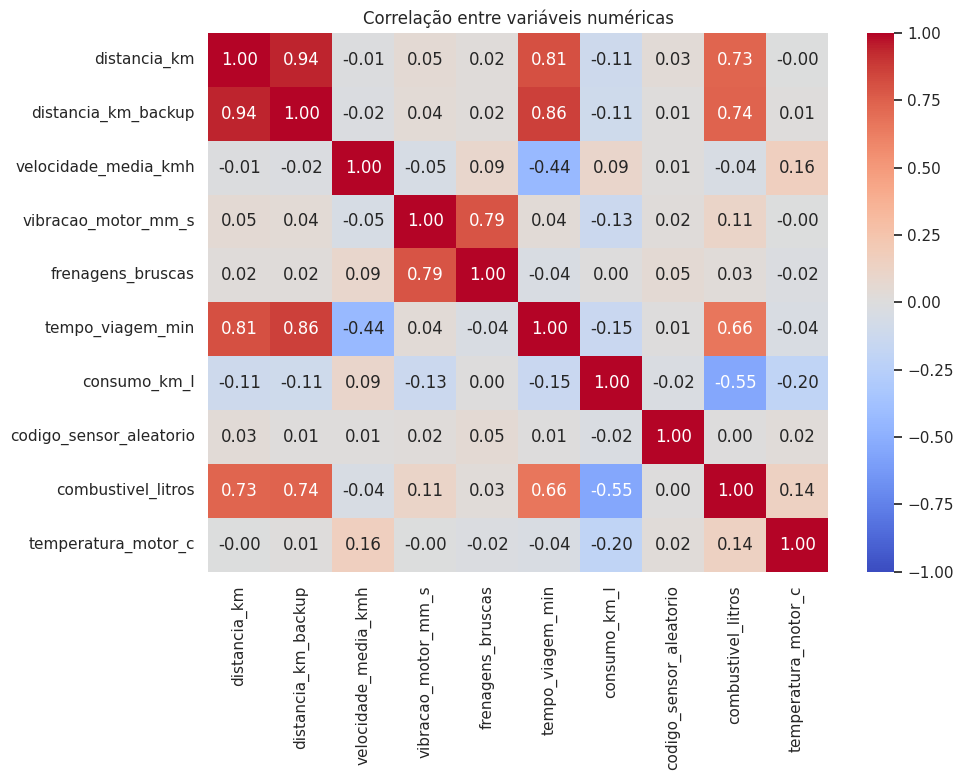

Colunas removidas: ['id_viagem', 'codigo_sensor_aleatorio', 'distancia_km_backup']
Dimensões após remoção: (520, 14)


,veiculo,tipo_veiculo,motorista,distancia_km,velocidade_media_kmh,vibracao_motor_mm_s,frenagens_bruscas,tempo_viagem_min,consumo_km_l,status_manutencao,risco_falha,data_viagem,combustivel_litros,temperatura_motor_c
0,V003,caminhao,Eduardo Rocha,39.54,65.44,3.03,2.0,48.38,4.81,normal,baixo,2026-03-01 06:00:00,8.214,95.400
1,V020,van,Bruno Lima,143.13,62.08,1.64,6.0,136.25,10.26,atencao,medio,2026-03-01 09:00:00,13.940,82.500
2,V017,onibus,Carla Mendes,115.91,61.79,2.21,3.0,119.27,2.92,normal,baixo,2026-03-01 12:00:00,39.670,95.278
3,V011,onibus,Juliana Castro,56.05,62.92,2.93,3.0,55.35,3.10,normal,baixo,2026-03-01 15:00:00,18.056,90.600
4,V011,onibus,Diego Alves,39.40,65.39,3.08,3.0,35.31,3.01,normal,baixo,2026-03-01 18:00:00,13.070,92.800


In [ ]:
# ------------------------------------------------------------
# Atividade 9) Análise de redundância e remoção de atributos
# ------------------------------------------------------------

dados_sem_irrelevantes = dados_imputados.copy()

colunas_numericas = dados_sem_irrelevantes.select_dtypes(include="number").columns

plt.figure(figsize=(10, 7))
sns.heatmap(
    dados_sem_irrelevantes[colunas_numericas].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlação entre variáveis numéricas")
plt.show()

colunas_remover_modelagem = [
    "id_viagem",
    "codigo_sensor_aleatorio",
    "distancia_km_backup"
]

dados_sem_irrelevantes = dados_sem_irrelevantes.drop(columns=colunas_remover_modelagem)

print("Colunas removidas:", colunas_remover_modelagem)
print("Dimensões após remoção:", dados_sem_irrelevantes.shape)

display(dados_sem_irrelevantes.head())


### Interpretação esperada

Identificadores e códigos aleatórios geralmente não têm valor preditivo. Atributos redundantes podem aumentar complexidade sem acrescentar informação útil.

## Atividade 10 — Outliers com IQR

### O que você deve fazer

Aplique IQR em:

- `vibracao_motor_mm_s`;
- `frenagens_bruscas`;
- `temperatura_motor_c`;
- `combustivel_litros`.

Teste `fator=1.5` e depois `fator=3.0`.

### Recursos úteis

- `.quantile(0.25)`;
- `.quantile(0.75)`;
- IQR = Q3 - Q1;
- `.between(...)`.

In [ ]:
# ------------------------------------------------------------
# Atividade 10) Detecção de outliers com IQR
# ------------------------------------------------------------

def criar_mascara_sem_outliers_iqr(df, colunas, fator=1.5):
    mascara_final = pd.Series(True, index=df.index)

    for coluna in colunas:
        q1 = df[coluna].quantile(0.25)
        q3 = df[coluna].quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - fator * iqr
        limite_superior = q3 + fator * iqr

        mascara_coluna = df[coluna].between(limite_inferior, limite_superior)

        qtd_outliers = (~mascara_coluna).sum()
        print(f"{coluna}: {qtd_outliers} outliers pelo IQR com fator={fator}")

        mascara_final = mascara_final & mascara_coluna

    return mascara_final


colunas_outliers = [
    "vibracao_motor_mm_s",
    "frenagens_bruscas",
    "temperatura_motor_c",
    "combustivel_litros"
]

dados_base_outliers = dados_sem_irrelevantes.copy()

mascara_iqr = criar_mascara_sem_outliers_iqr(
    dados_base_outliers,
    colunas=colunas_outliers,
    fator=1.5
)

dados_iqr = dados_base_outliers[mascara_iqr].copy()

print("\nLinhas antes:", dados_base_outliers.shape[0])
print("Linhas depois do IQR:", dados_iqr.shape[0])
print("Linhas removidas:", dados_base_outliers.shape[0] - dados_iqr.shape[0])


vibracao_motor_mm_s: 13 outliers pelo IQR com fator=1.5
frenagens_bruscas: 12 outliers pelo IQR com fator=1.5
temperatura_motor_c: 3 outliers pelo IQR com fator=1.5
combustivel_litros: 13 outliers pelo IQR com fator=1.5

Linhas antes: 520
Linhas depois do IQR: 491
Linhas removidas: 29


### Interpretação esperada

O IQR é simples e robusto. O fator escolhido altera o rigor da remoção. Fator menor remove mais; fator maior remove menos.

## Atividade 11 — Outliers com z-score

### O que você deve fazer

Aplique z-score nas mesmas variáveis da atividade anterior.

Teste `limite_z=3.0` e depois `limite_z=2.5`.

### Recursos úteis

- `zscore(...)`;
- `np.abs(...)`;
- `.all(axis=1)`.

In [ ]:
# ------------------------------------------------------------
# Atividade 11) Detecção de outliers com z-score
# ------------------------------------------------------------

dados_zscore_base = dados_base_outliers.copy()

limite_z = 3.0

z = dados_zscore_base[colunas_outliers].apply(zscore, nan_policy="omit")

mascara_sem_outlier_z = (np.abs(z) <= limite_z).all(axis=1)

dados_zscore_filtrado = dados_zscore_base[mascara_sem_outlier_z].copy()

print("Linhas antes:", dados_zscore_base.shape[0])
print("Linhas depois do z-score:", dados_zscore_filtrado.shape[0])
print("Linhas removidas:", dados_zscore_base.shape[0] - dados_zscore_filtrado.shape[0])

# Comparação com limite_z = 2.5
limite_z_2 = 2.5
mascara_z_2 = (np.abs(z) <= limite_z_2).all(axis=1)
dados_zscore_filtrado_2 = dados_zscore_base[mascara_z_2].copy()
print("\nCom limite_z = 2.5:")
print("Linhas depois:", dados_zscore_filtrado_2.shape[0])
print("Linhas removidas:", dados_zscore_base.shape[0] - dados_zscore_filtrado_2.shape[0])


Linhas antes: 520
Linhas depois do z-score: 505
Linhas removidas: 15

Com limite_z = 2.5:
Linhas depois: 494
Linhas removidas: 26


### Interpretação esperada

O z-score usa média e desvio padrão. Por isso, costuma funcionar melhor em distribuições aproximadamente simétricas e pode ser sensível a valores muito extremos.

## Atividade 12 — Outliers com DBSCAN

### O que você deve fazer

Use DBSCAN para detectar outliers multivariados.

Teste valores diferentes de `eps`, como 1.4, 1.8 e 2.2.

### Recursos úteis

- `StandardScaler()`;
- `.fit_transform(...)`;
- `DBSCAN(eps=..., min_samples=...)`;
- `.fit_predict(...)`;
- rótulo `-1` como possível outlier.

In [ ]:
# ------------------------------------------------------------
# Atividade 12) Detecção de outliers com DBSCAN
# ------------------------------------------------------------

dados_dbscan_base = dados_base_outliers.copy()

colunas_dbscan = [
    "distancia_km",
    "combustivel_litros",
    "velocidade_media_kmh",
    "temperatura_motor_c",
    "vibracao_motor_mm_s",
    "frenagens_bruscas",
    "tempo_viagem_min"
]

scaler = StandardScaler()
X_dbscan = scaler.fit_transform(dados_dbscan_base[colunas_dbscan])

dbscan = DBSCAN(eps=1.8, min_samples=8)
rotulos = dbscan.fit_predict(X_dbscan)

dados_dbscan_base["cluster_dbscan"] = rotulos
dados_dbscan_base["outlier_dbscan"] = dados_dbscan_base["cluster_dbscan"] == -1

print("Contagem de rótulos do DBSCAN:")
display(dados_dbscan_base["cluster_dbscan"].value_counts().sort_index())

print("\nQuantidade de outliers pelo DBSCAN:")
print(dados_dbscan_base["outlier_dbscan"].sum())

dados_dbscan_filtrado = dados_dbscan_base[~dados_dbscan_base["outlier_dbscan"]].copy()
dados_dbscan_filtrado = dados_dbscan_filtrado.drop(columns=["cluster_dbscan", "outlier_dbscan"])

print("\nLinhas antes:", dados_dbscan_base.shape[0])
print("Linhas depois do DBSCAN:", dados_dbscan_filtrado.shape[0])


Contagem de rótulos do DBSCAN:


,count
cluster_dbscan,
-1,19
0,501



Quantidade de outliers pelo DBSCAN:
19

Linhas antes: 520
Linhas depois do DBSCAN: 501


### Interpretação esperada

O DBSCAN identifica pontos incomuns considerando várias variáveis ao mesmo tempo. Ele é útil para anomalias multivariadas, mas depende bastante dos parâmetros `eps` e `min_samples`.

## Atividade 13 — Comparação dos métodos de outliers

### O que você deve fazer

Compare IQR, z-score e DBSCAN.

Responda:

1. Qual método removeu mais registros?
2. Qual foi mais conservador?
3. A média de vibração mudou?
4. A média de frenagens bruscas mudou?
5. Qual versão da base você escolheria para continuar? Justifique.

In [ ]:
# ------------------------------------------------------------
# Atividade 13) Comparação entre métodos de outliers
# ------------------------------------------------------------

#Apenas entenda e execute o códiog a seguir

comparacao_outliers = pd.DataFrame({
    "base": ["original_tratada", "IQR", "z-score", "DBSCAN"],
    "qtd_linhas": [
        dados_base_outliers.shape[0],
        dados_iqr.shape[0],
        dados_zscore_filtrado.shape[0],
        dados_dbscan_filtrado.shape[0]
    ],
    "media_vibracao": [
        dados_base_outliers["vibracao_motor_mm_s"].mean(),
        dados_iqr["vibracao_motor_mm_s"].mean(),
        dados_zscore_filtrado["vibracao_motor_mm_s"].mean(),
        dados_dbscan_filtrado["vibracao_motor_mm_s"].mean()
    ],
    "media_frenagens": [
        dados_base_outliers["frenagens_bruscas"].mean(),
        dados_iqr["frenagens_bruscas"].mean(),
        dados_zscore_filtrado["frenagens_bruscas"].mean(),
        dados_dbscan_filtrado["frenagens_bruscas"].mean()
    ],
    "media_temperatura": [
        dados_base_outliers["temperatura_motor_c"].mean(),
        dados_iqr["temperatura_motor_c"].mean(),
        dados_zscore_filtrado["temperatura_motor_c"].mean(),
        dados_dbscan_filtrado["temperatura_motor_c"].mean()
    ]
})

display(comparacao_outliers.round(3))

,base,qtd_linhas,media_vibracao,media_frenagens,media_temperatura
0,original_tratada,520,2.615,1.577,88.772
1,IQR,491,2.469,1.110,88.782
2,z-score,505,2.478,1.139,88.754
3,DBSCAN,501,2.479,1.144,88.761


### Interpretação esperada

Não existe um único método correto. A escolha deve considerar o problema, a quantidade de dados removidos, a interpretação industrial e o objetivo da análise.

## Atividade 14 — Salvamento da base limpa

### O que você deve fazer

Escolha uma versão tratada e salve em CSV.

Nesta implementação parcial, usamos `dados_iqr`. Você pode trocar por `dados_zscore_filtrado` ou `dados_dbscan_filtrado`.

### Recurso útil

- `.to_csv("arquivo.csv", index=False)`.

In [ ]:
# ------------------------------------------------------------
# Atividade 14) Salvamento da base limpa
# ------------------------------------------------------------

#Apenas execute o código a seguir

dados_finais = dados_iqr.copy()

nome_saida = "dados_frota_iot_limpos.csv"
dados_finais.to_csv(nome_saida, index=False)

print(f"Base limpa salva em: {nome_saida}")
print("Dimensões da base final:", dados_finais.shape)

display(dados_finais.head())

Base limpa salva em: dados_frota_iot_limpos.csv
Dimensões da base final: (491, 14)


,veiculo,tipo_veiculo,motorista,distancia_km,velocidade_media_kmh,vibracao_motor_mm_s,frenagens_bruscas,tempo_viagem_min,consumo_km_l,status_manutencao,risco_falha,data_viagem,combustivel_litros,temperatura_motor_c
0,V003,caminhao,Eduardo Rocha,39.54,65.44,3.03,2.0,48.38,4.81,normal,baixo,2026-03-01 06:00:00,8.214,95.400
2,V017,onibus,Carla Mendes,115.91,61.79,2.21,3.0,119.27,2.92,normal,baixo,2026-03-01 12:00:00,39.670,95.278
3,V011,onibus,Juliana Castro,56.05,62.92,2.93,3.0,55.35,3.10,normal,baixo,2026-03-01 15:00:00,18.056,90.600
4,V011,onibus,Diego Alves,39.40,65.39,3.08,3.0,35.31,3.01,normal,baixo,2026-03-01 18:00:00,13.070,92.800
5,V022,van,Diego Alves,20.41,32.70,2.16,1.0,48.35,10.20,normal,baixo,2026-03-01 21:00:00,2.006,86.700


### Interpretação esperada

A base limpa salva pode ser usada nas próximas aulas para transformação de dados, encoding, seleção de atributos e modelagem.

## Atividade 15 — Preparação para as próximas aulas

### O que você deve fazer

Analise a base final e responda:

1. Quais colunas são categóricas nominais?
2. Quais colunas poderiam precisar de encoding?
3. Quais colunas numéricas têm escalas muito diferentes?
4. Qual variável poderia ser alvo de classificação?
5. Qual variável poderia ser alvo de regressão?
6. Quais colunas você removeria antes da modelagem? Por quê?

In [ ]:
print("Colunas da base final:")
print(list(dados_finais.columns))

print("\nTipos das colunas:")
display(dados_finais.dtypes)

print("\nColunas categóricas:")
colunas_categoricas = list(dados_finais.select_dtypes(include="object").columns)
print(colunas_categoricas)

print("\nColunas numéricas:")
colunas_numericas = list(dados_finais.select_dtypes(include="number").columns)
print(colunas_numericas)

categoricas_para_encoding = [
    "veiculo",
    "tipo_veiculo",
    "motorista",
    "status_manutencao",
]

numericas_para_escalonamento = [
    "distancia_km",
    "combustivel_litros",
    "velocidade_media_kmh",
    "temperatura_motor_c",
    "vibracao_motor_mm_s",
    "frenagens_bruscas",
    "tempo_viagem_min",
    "consumo_km_l",
]

possivel_alvo_classificacao = "risco_falha"
possivel_alvo_regressao = "combustivel_litros"

print("\nPossível alvo de classificação:", possivel_alvo_classificacao)
print("Possível alvo de regressão:", possivel_alvo_regressao)


Colunas da base final:
['veiculo', 'tipo_veiculo', 'motorista', 'distancia_km', 'velocidade_media_kmh', 'vibracao_motor_mm_s', 'frenagens_bruscas', 'tempo_viagem_min', 'consumo_km_l', 'status_manutencao', 'risco_falha', 'data_viagem', 'combustivel_litros', 'temperatura_motor_c']

Tipos das colunas:


,0
veiculo,object
tipo_veiculo,object
motorista,object
distancia_km,float64
velocidade_media_kmh,float64
vibracao_motor_mm_s,float64
frenagens_bruscas,float64
tempo_viagem_min,float64
consumo_km_l,float64
status_manutencao,object



Colunas categóricas:
['veiculo', 'tipo_veiculo', 'motorista', 'status_manutencao', 'risco_falha']

Colunas numéricas:
['distancia_km', 'velocidade_media_kmh', 'vibracao_motor_mm_s', 'frenagens_bruscas', 'tempo_viagem_min', 'consumo_km_l', 'combustivel_litros', 'temperatura_motor_c']

Possível alvo de classificação: risco_falha
Possível alvo de regressão: combustivel_litros


## Entrega sugerida

Entregue um relatório curto com a seguinte estrutura:

| Etapa | Problema encontrado | Técnica aplicada | Resultado |
|---|---|---|---|
| Duplicatas | Linhas repetidas | `drop_duplicates()` | X linhas removidas |
| Ausentes | Temperatura, combustível etc. | Mediana/moda | X valores imputados |
| Categorias inconsistentes | Tipo de veículo/status | Padronização textual | Categorias unificadas |
| Unidades misturadas | Combustível e temperatura | Conversão para litros/°C | Novas colunas numéricas |
| Outliers | Vibração/frenagens | IQR, z-score ou DBSCAN | X registros removidos |
| Redundância | Backup/identificador | Remoção de colunas | Base simplificada |

Inclua também uma breve justificativa para a versão final da base escolhida.

## Conclusão

Nesta prática, você repetiu o pipeline de limpeza de dados em um novo contexto: monitoramento de frota com IoT.

A ideia é consolidar o raciocínio:

1. entender o problema;
2. diagnosticar problemas de dados;
3. limpar e padronizar registros;
4. imputar valores ausentes;
5. comparar métodos de outliers;
6. justificar decisões;
7. salvar uma base limpa para etapas futuras.

Esse processo prepara a base para transformação de dados, seleção de atributos e modelos de aprendizado de máquina.